# 🏦 Análisis Exploratorio del Dataset: Bank Marketing
**Objetivo:** Explorar los datos crudos, identificar inconsistencias ocultas (como valores "unknown") y definir un flujo de limpieza y transformación riguroso que luego llevaremos a nuestro entorno local en VS Code.


**Diccionario de Variables Clave:**
* `age`: Edad del cliente.
* `job`: Tipo de trabajo.
* `marital`: Estado civil.
* `balance`: Saldo medio anual en euros.
* `housing`: ¿Tiene crédito hipotecario?
* `loan`: ¿Tiene préstamos personales?
* `contact`: Tipo de comunicación (celular, teléfono fijo).
* `poutcome`: Resultado de la campaña de marketing anterior.
* `y`: **Variable Objetivo.** ¿El cliente suscribió un depósito a plazo? ('yes' o 'no').

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuración visual para que los gráficos se vean profesionales
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Cargamos el dataset
df = pd.read_csv('../data/raw/bank-full.csv', sep=';')
print(f"Dimensiones del dataset: {df.shape}")
df.head()

Dimensiones del dataset: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## 🕵️‍♂️ 1. El problema de los valores ocultos ("unknown")
En muchos datasets reales, los valores nulos no vienen como `NaN`, sino enmascarados con texto. En este caso, el banco registró los datos faltantes como la palabra `"unknown"`.

Antes de usar herramientas automáticas de limpieza, necesitamos cuantificar cuántos "unknown" existen y en qué variables.

--- Conteo de 'unknown' por columna ---
poutcome     36959
contact      13020
education     1857
job            288
dtype: int64


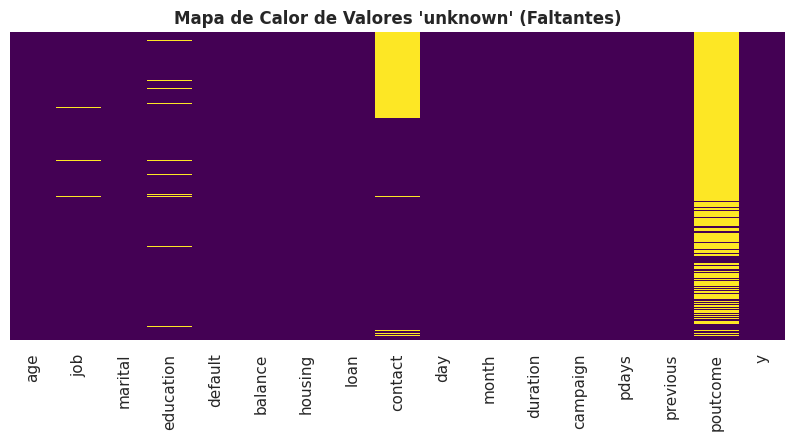

In [9]:
# Contar cuántos 'unknown' hay exactamente en cada columna
print("--- Conteo de 'unknown' por columna ---")

# Creamos una máscara booleana y sumamos los True
conteo_unknown = (df == 'unknown').sum()

# Filtramos para mostrar solo las columnas que sí tienen 'unknown'
print(conteo_unknown[conteo_unknown > 0].sort_values(ascending=False))

# Mapa de Calor Optimizado (Sin crear copias del DataFrame)
plt.figure(figsize=(10, 4))

# Pasamos la condición directamente. True (1) será un color, False (0) será otro.
sns.heatmap(df == 'unknown', cbar=False, cmap="viridis", yticklabels=False)

plt.title("Mapa de Calor de Valores 'unknown' (Faltantes)", fontweight='bold')
plt.show()

## 2. Variable Objetivo (y)
¿El cliente suscribió un depósito a plazo? ('yes' o 'no')

/tmp/ipykernel_34646/2333690336.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='y', palette='viridis')


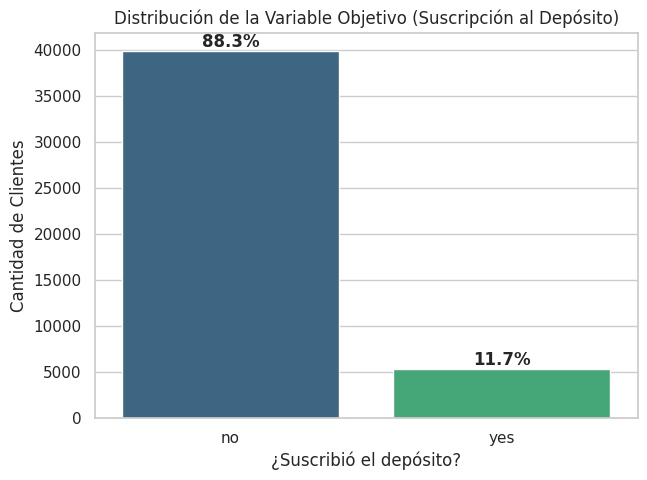

In [4]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x='y', palette='viridis')
plt.title('Distribución de la Variable Objetivo (Suscripción al Depósito)')
plt.ylabel('Cantidad de Clientes')
plt.xlabel('¿Suscribió el depósito?')

# Agregar los porcentajes arriba de las barras
total = len(df)
for p in ax.patches:
    porcentaje = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(porcentaje, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.show()

## 3. EDA 

Generando distribuciones numéricas...


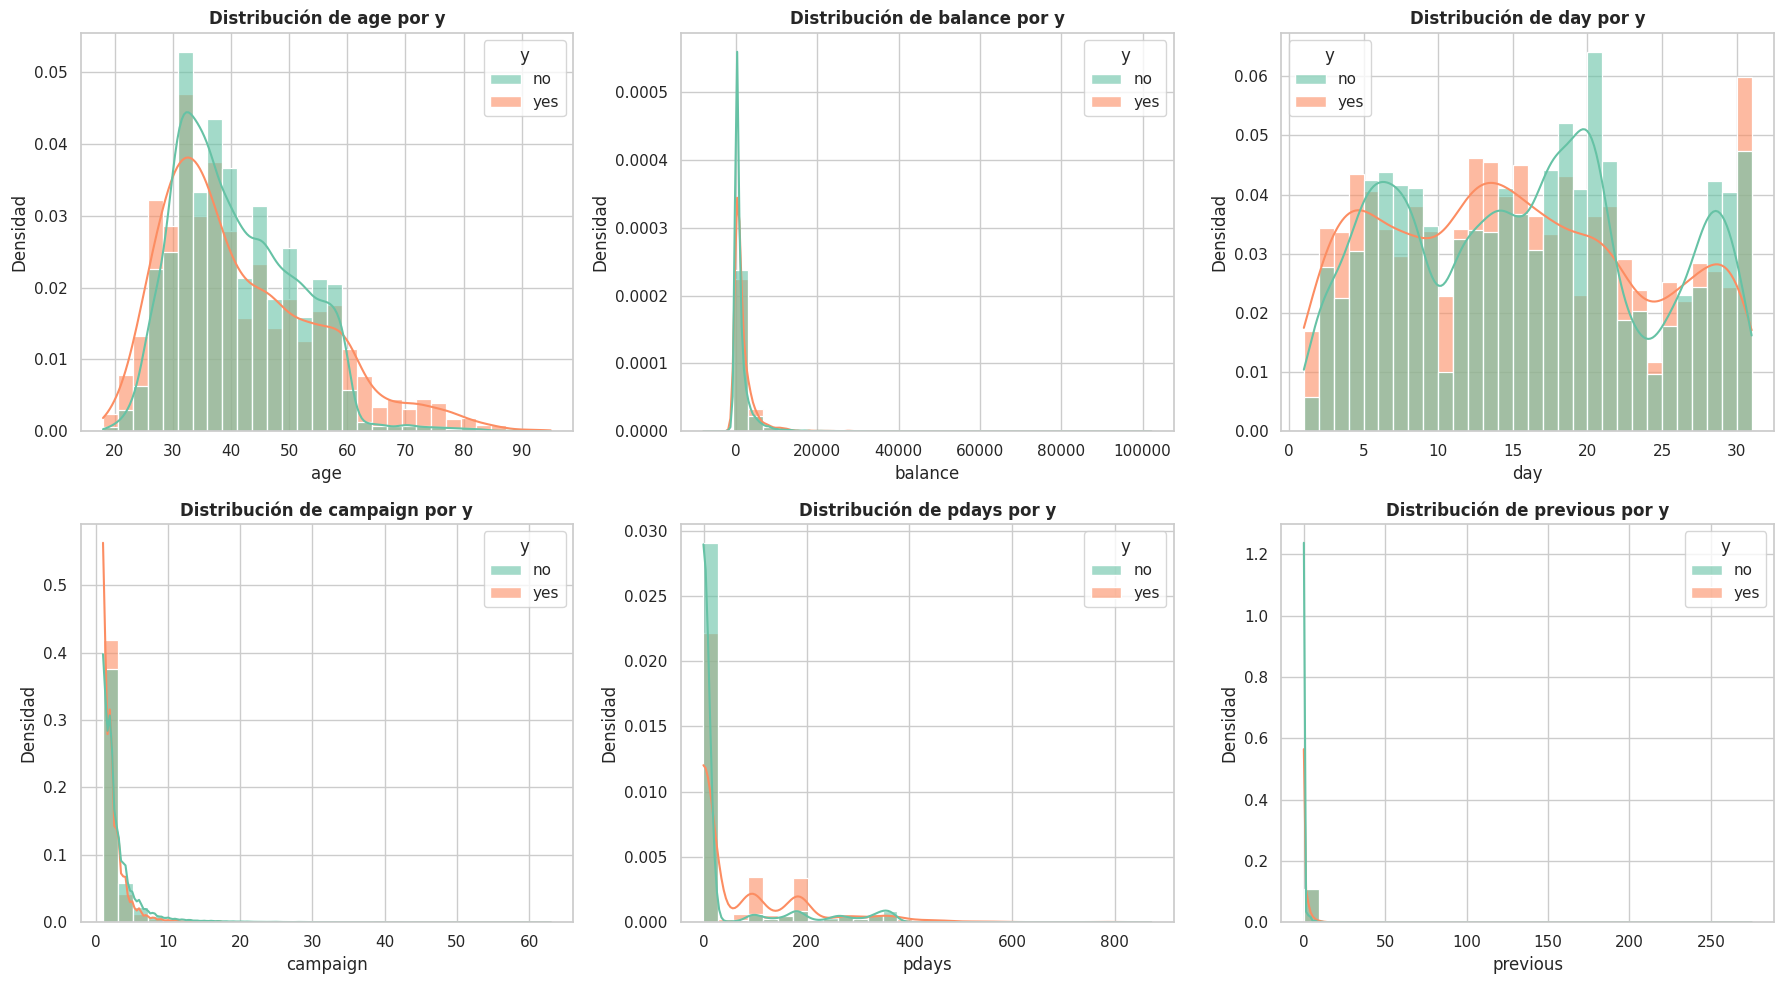


Generando frecuencias categóricas...


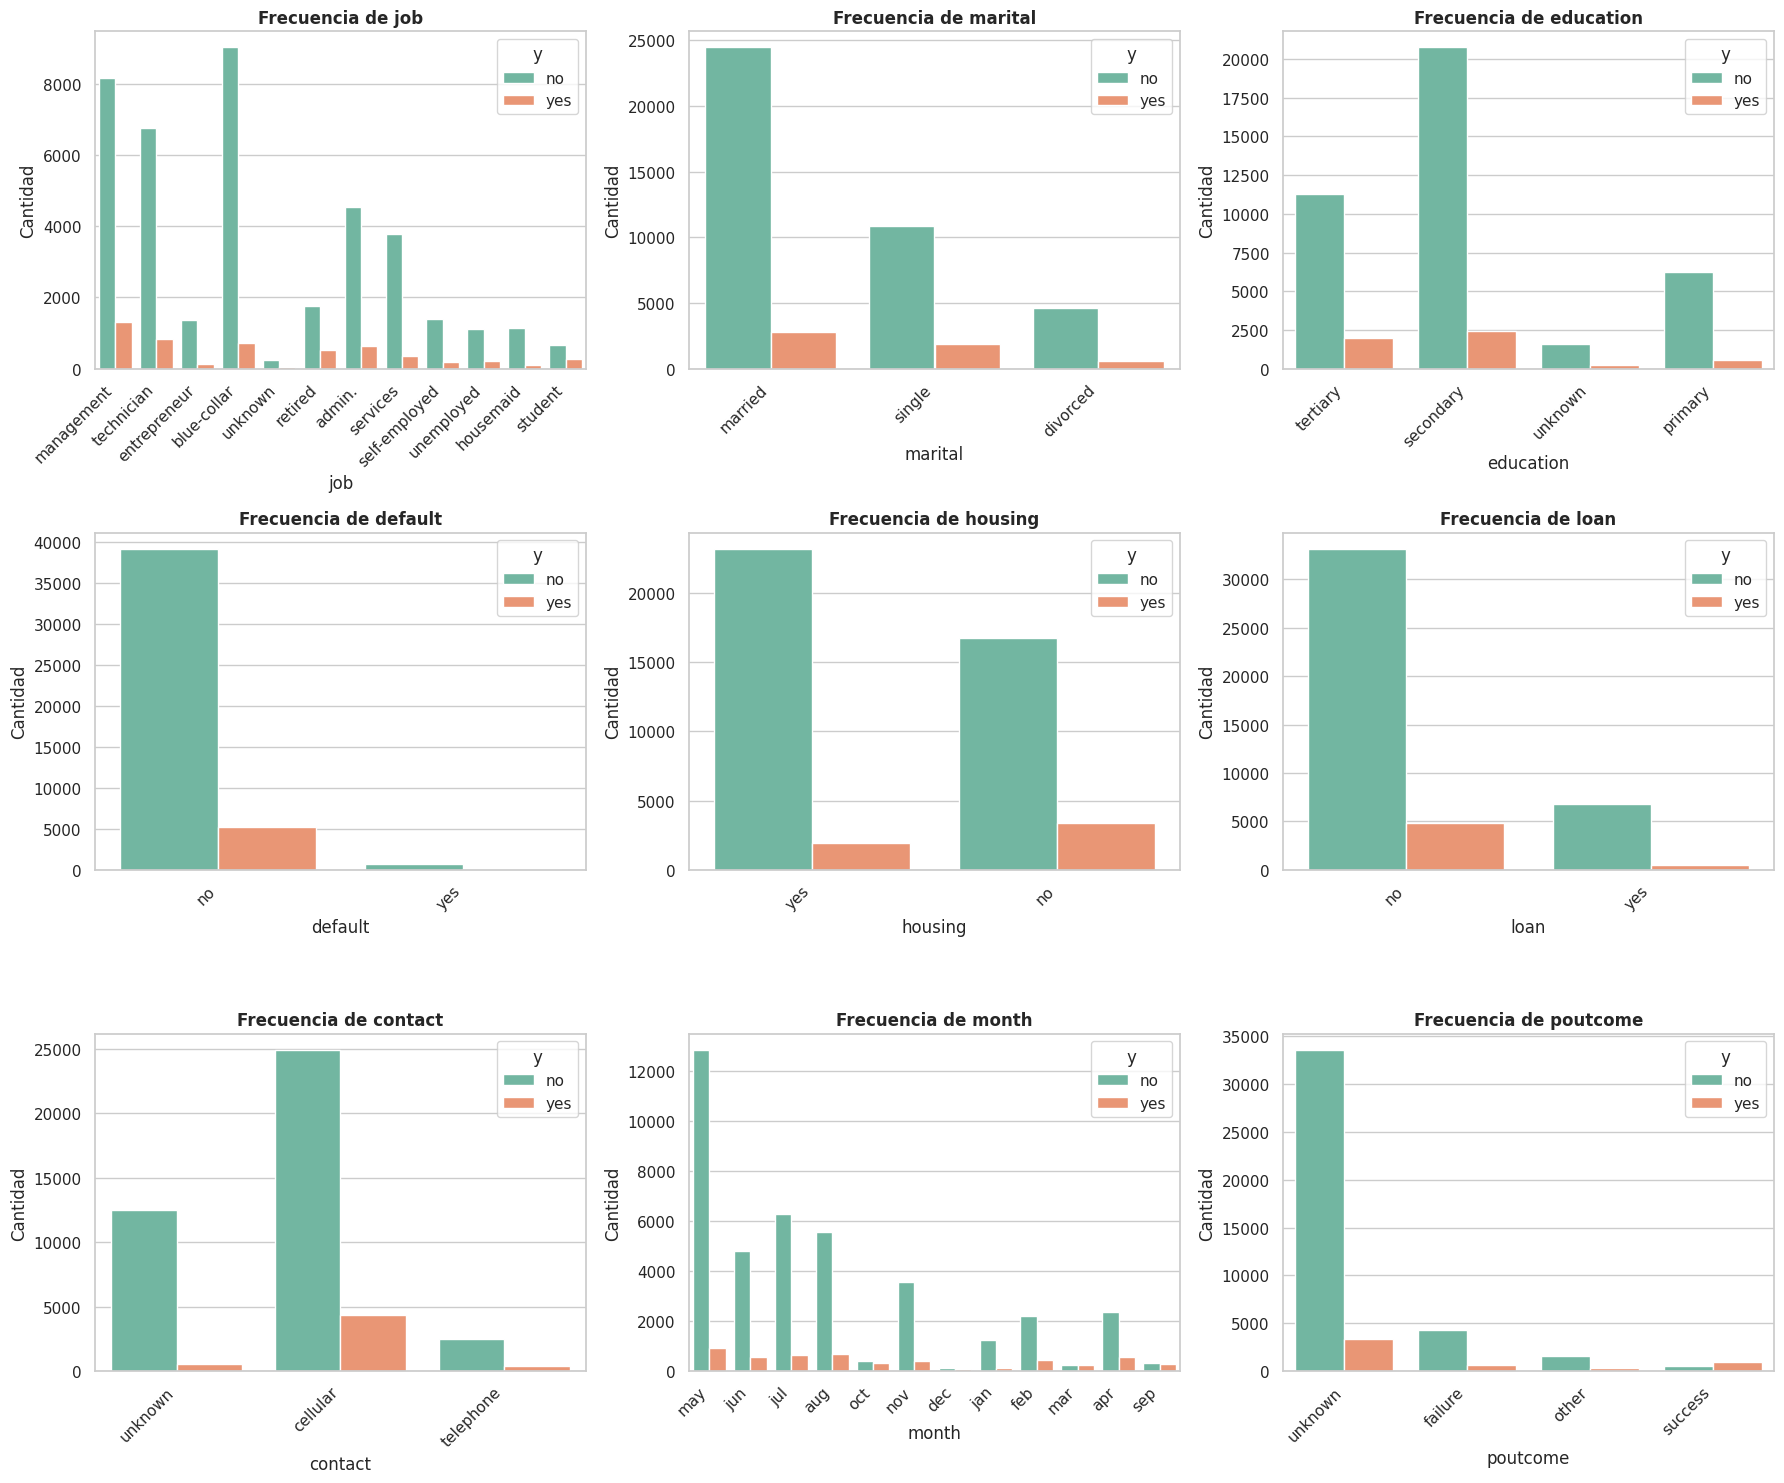

In [13]:

def plot_numeric_distributions(df, target_col):
    """Genera histogramas superpuestos para variables numéricas."""
    num_cols = df.select_dtypes(include=['int64', 'float64']).columns
    # Excluimos 'duration' por Data Leakage (Fuga de Datos)
    num_cols = [c for c in num_cols if c != target_col and c != 'duration']

    n_cols = 3
    n_rows = int(np.ceil(len(num_cols) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(num_cols):
        # PRO-TIP: Añadimos stat='density' y common_norm=False
        sns.histplot(data=df, x=col, hue=target_col, kde=True, ax=axes[i],
                     bins=30, alpha=0.6, stat='density', common_norm=False, palette='Set2')
        axes[i].set_title(f'Distribución de {col} por {target_col}', fontweight='bold')
        axes[i].set_ylabel('Densidad')

    # Eliminar subplots vacíos si los hay
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

def plot_categorical_counts(df, target_col):
    """Genera gráficos de barras para variables categóricas."""
    cat_cols = df.select_dtypes(include=['object', 'category']).columns
    cat_cols = [c for c in cat_cols if c != target_col]

    n_cols = 3
    n_rows = int(np.ceil(len(cat_cols) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(cat_cols):
        sns.countplot(data=df, x=col, hue=target_col, ax=axes[i], palette="Set2")
        axes[i].set_title(f'Frecuencia de {col}', fontweight='bold')
        # PRO-TIP: Alineación a la derecha para que los textos largos no se pisen
        axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')
        axes[i].set_ylabel('Cantidad')

    # Eliminar subplots vacíos si los hay
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

print("Generando distribuciones numéricas...")
plot_numeric_distributions(df, target_col='y')

print("\nGenerando frecuencias categóricas...")
plot_categorical_counts(df, target_col='y')

## 4. Outliers

Calculando límites IQR y aplicando recorte (Capping) a todas las variables numéricas...
Registros originales: 45211
Registros tras el tratamiento: 45211 (¡Sin perder clientes!)

--------------------------------------------------


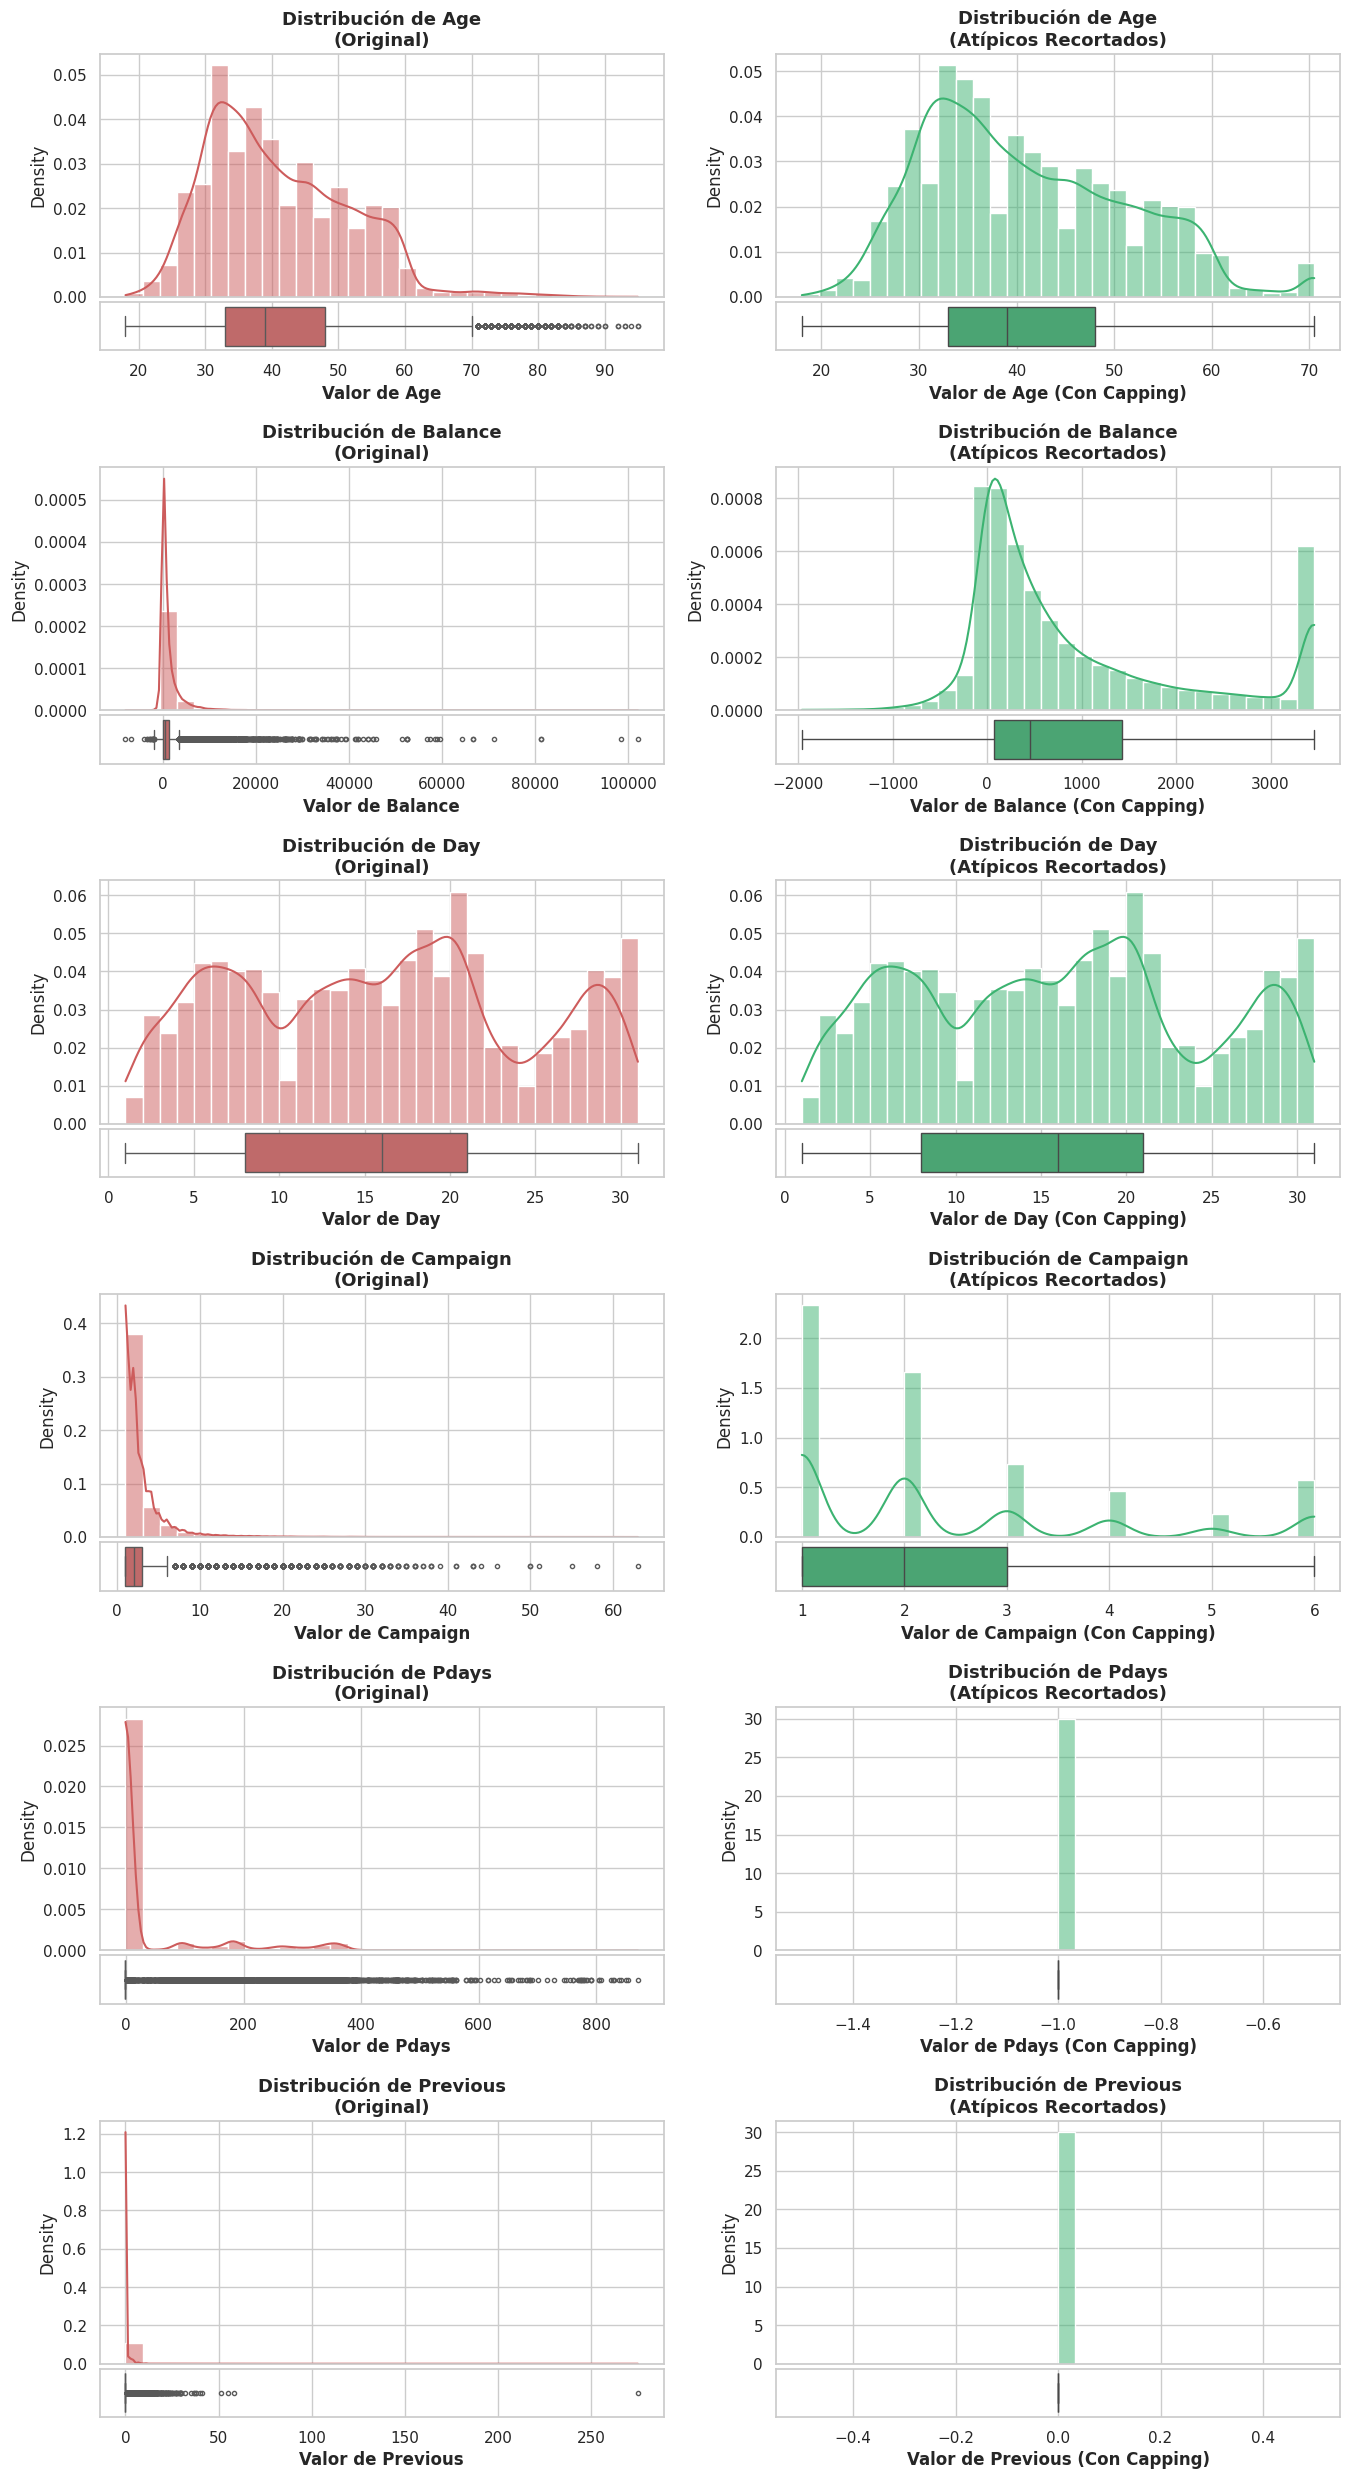

In [17]:
# 1. Identificar TODAS las variables numéricas automáticamente
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
# Excluimos 'duration' por la Fuga de Datos (Data Leakage)
numerical_cols = [col for col in numerical_cols if col != 'duration']

# 2. Creamos copia y aplicamos Capping a TODAS las columnas numéricas
df_sin_outliers = df.copy()

print("Calculando límites IQR y aplicando recorte (Capping) a todas las variables numéricas...")
for col in numerical_cols:
    Q1 = df_sin_outliers[col].quantile(0.25)
    Q3 = df_sin_outliers[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_sin_outliers[col] = np.clip(df_sin_outliers[col], lower_bound, upper_bound)

print(f"Registros originales: {len(df)}")
print(f"Registros tras el tratamiento: {len(df_sin_outliers)} (¡Sin perder clientes!)\n")
print("-" * 50)

# 3. Visualización Dinámica Avanzada (Ejes Compartidos)
# Creamos tantas filas como variables numéricas tengamos
fig, axs = plt.subplots(len(numerical_cols), 2, figsize=(16, 5 * len(numerical_cols)))

for i, col in enumerate(numerical_cols):

    nombre_columna = col.capitalize()

    # ===========================================================
    # COLUMNA IZQUIERDA: DATOS ORIGINALES (CON OUTLIERS)
    # ===========================================================
    ax_hist_orig = axs[i, 0]
    ax_hist_orig.set_title(f'Distribución de {nombre_columna}\n(Original)', fontweight='bold', fontsize=13)

    # Histograma
    sns.histplot(df[col].dropna(), bins=30, kde=True, ax=ax_hist_orig, color='indianred', stat='density')

    # EL TRUCO: Ocultar textos y números del eje X del histograma
    ax_hist_orig.set_xlabel('')
    ax_hist_orig.tick_params(labelbottom=False)

    # Boxplot (ancho 100%, altura 20%, posicionado justo debajo)
    ax_box_orig = ax_hist_orig.inset_axes([0, -0.22, 1, 0.2])
    sns.boxplot(x=df[col].dropna(), ax=ax_box_orig, color='indianred', fliersize=3)

    # EL TRUCO: Forzar al boxplot a tener la misma escala exacta que el histograma
    ax_box_orig.set_xlim(ax_hist_orig.get_xlim())
    ax_box_orig.set_xlabel(f'Valor de {nombre_columna}', fontweight='bold')

    # ===========================================================
    # COLUMNA DERECHA: DATOS RECORTADOS (CAPPING)
    # ===========================================================
    ax_hist_cap = axs[i, 1]
    ax_hist_cap.set_title(f'Distribución de {nombre_columna}\n(Atípicos Recortados)', fontweight='bold', fontsize=13)

    # Histograma
    sns.histplot(df_sin_outliers[col].dropna(), bins=30, kde=True, ax=ax_hist_cap, color='mediumseagreen', stat='density')

    # EL TRUCO: Ocultar textos y números del eje X del histograma
    ax_hist_cap.set_xlabel('')
    ax_hist_cap.tick_params(labelbottom=False)

    # Boxplot
    ax_box_cap = ax_hist_cap.inset_axes([0, -0.22, 1, 0.2])
    sns.boxplot(x=df_sin_outliers[col].dropna(), ax=ax_box_cap, color='mediumseagreen', fliersize=3)

    # EL TRUCO: Forzar al boxplot a tener la misma escala exacta que el histograma
    ax_box_cap.set_xlim(ax_hist_cap.get_xlim())
    ax_box_cap.set_xlabel(f'Valor de {nombre_columna} (Con Capping)', fontweight='bold')

# Ajustar márgenes para que los boxplots inferiores no choquen con el título de la siguiente fila
plt.subplots_adjust(hspace=0.7)
plt.show()

## 5. Correlación

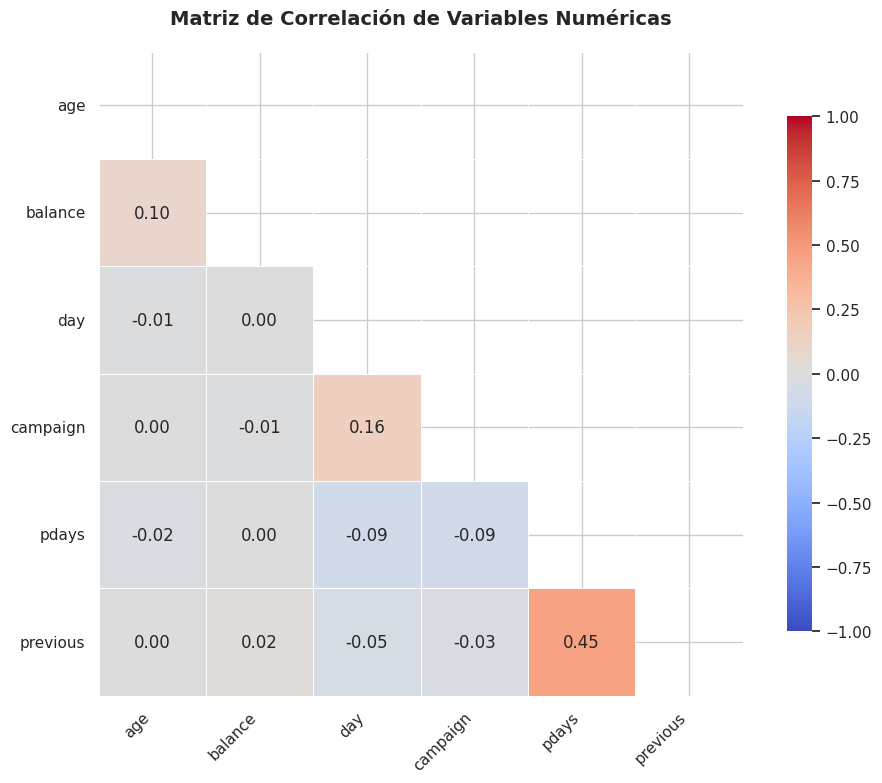

In [19]:
# 1. Seleccionar solo las variables numéricas del dataset original
# (Excluimos 'duration' por la Fuga de Datos)
num_cols_corr = df.select_dtypes(include=['int64', 'float64']).columns
num_cols_corr = [c for c in num_cols_corr if c != 'duration']

# 2. Calcular la matriz de correlación de Pearson
matriz_correlacion = df[num_cols_corr].corr()

# --- EL TRUCO VISUAL: Crear una máscara para el triángulo superior ---
# np.triu_indices_from devuelve los índices del triángulo superior
mask = np.zeros_like(matriz_correlacion, dtype=bool)
mask[np.triu_indices_from(mask)] = True

# 3. Configurar la visualización
plt.figure(figsize=(10, 8))

# Generar un Heatmap aplicando la máscara (mask=mask)
sns.heatmap(matriz_correlacion,
            mask=mask,               # <--- Aplicamos la máscara aquí
            annot=True,
            cmap="coolwarm",
            fmt=".2f",
            linewidths=0.5,
            vmin=-1,
            vmax=1,
            square=True,
            cbar_kws={"shrink": .8})

plt.title("Matriz de Correlación de Variables Numéricas", fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()